In [14]:
import requests
from bs4 import BeautifulSoup

In [81]:
from curl_cffi import requests
import pandas as pd

url = "https://www.sofascore.com/api/v1/unique-tournament/17/season/76986/events/round/30"

response = requests.get(url, impersonate="chrome110")

data = response.json()

events = data["events"]

matches = pd.json_normalize(events)

print(matches[['id','homeTeam.name','awayTeam.name']])

         id      homeTeam.name           awayTeam.name
0  14023988            Burnley             Bournemouth
1  14023996         Sunderland  Brighton & Hove Albion
2  14023987            Arsenal                 Everton
3  14023990            Chelsea        Newcastle United
4  14023993    West Ham United         Manchester City
5  14023991     Crystal Palace            Leeds United
6  14023994  Manchester United             Aston Villa
7  14023995  Nottingham Forest                  Fulham
8  14023992          Liverpool       Tottenham Hotspur
9  15408501          Brentford           Wolverhampton


# Get the match IDs

In [49]:
match_ids = matches["id"].tolist()

print(match_ids)

[14023988, 14023996, 14023987, 14023990, 14023993, 14023991, 14023994, 14023995, 14023992, 15408501]


# Now scrape the shotmaps

In [50]:
all_shots = []

for match_id in match_ids:

    url = f"https://www.sofascore.com/api/v1/event/{match_id}/shotmap"

    r = requests.get(url, impersonate="chrome110")
    data = r.json()

    if "shotmap" not in data:
        continue

    shots = pd.json_normalize(data["shotmap"])
    shots["match_id"] = match_id

    all_shots.append(shots)

# Combine everything

In [51]:
shots_df = pd.concat(all_shots)

print(shots_df.head())

   isHome shotType           situation    bodyPart goalMouthLocation  \
0   False     miss            assisted        head             right   
1   False     miss            assisted  right-foot              left   
2    True     miss  throw-in-set-piece  right-foot              left   
3   False     miss            assisted   left-foot              left   
4    True    block            assisted   left-foot        low-centre   

         xg  xgot       id  time  addedTime  ...  player.lastName  \
0  0.363221   0.0  6885202    90        6.0  ...              NaN   
1  0.501232   0.0  6885147    90        3.0  ...                    
2  0.030605   0.0  6885017    82        NaN  ...                    
3  0.017133   0.0  6884956    79        NaN  ...              NaN   
4  0.022318   0.0  6884947    77        NaN  ...                    

   player.sofascoreId  goalkeeper.sofascoreId  blockCoordinates.x  \
0                 NaN                     NaN                 NaN   
1          Ene

In [52]:
shots_df.head()

,isHome,shotType,situation,bodyPart,goalMouthLocation,xg,xgot,id,time,addedTime,...,player.lastName,player.sofascoreId,goalkeeper.sofascoreId,blockCoordinates.x,blockCoordinates.y,blockCoordinates.z,draw.block.x,draw.block.y,match_id,goalType
0,False,miss,assisted,head,right,0.363221,0.0,6885202,90,6.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14023988,NaN
1,False,miss,assisted,right-foot,left,0.501232,0.0,6885147,90,3.0,...,,EnesUnal16,NaN,NaN,NaN,NaN,NaN,NaN,14023988,NaN
2,True,miss,throw-in-set-piece,right-foot,left,0.030605,0.0,6885017,82,NaN,...,,hannibal_mj,dj.petrovic12,NaN,NaN,NaN,NaN,NaN,14023988,NaN
3,False,miss,assisted,left-foot,left,0.017133,0.0,6884956,79,NaN,...,NaN,amine_ad10,NaN,20.6,63.5,0.0,63.5,20.6,14023988,NaN
4,True,block,assisted,left-foot,low-centre,0.022318,0.0,6884947,77,NaN,...,,NaN,dj.petrovic12,11.7,67.9,0.0,67.9,11.7,14023988,NaN


In [82]:
shots_df.to_csv("shots.csv", index=False)

In [83]:
from google.colab import files
files.download("shots.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [59]:
player_stats = round30_stats[round30_stats.index.notnull() & (round30_stats.index!="")]

In [60]:
shots_df.isnull().sum()

,0
isHome,0
shotType,0
situation,0
bodyPart,0
goalMouthLocation,0
...,...
draw.block.x,102
draw.block.y,102
match_id,0
goalType,246


# Shots per player this round

In [61]:
round_shots = shots_df.groupby("player.lastName").size().sort_values(ascending=False)
print(round_shots)

player.lastName
             84
O’Reilly      4
Armstrong     3
McNeil        3
Diarra        1
dtype: int64


In [55]:
shots_df['goal'] = shots_df['shotType'] == 'goal'

round_stats = shots_df.groupby('player.lastName').agg(
    shots=('player.lastName','count'),
    goals=('goal','sum'),
    total_xg=('xg','sum')
).sort_values('total_xg', ascending=False)

print(round_stats)

                 shots  goals  total_xg
player.lastName                        
                    84      6  8.829695
O’Reilly             4      0  0.623891
Armstrong            3      1  0.474348
McNeil               3      0  0.344697
Diarra               1      0  0.021680


# Top shooters last week (Round 30)

In [58]:
import pandas as pd

# Make sure goal column exists
shots_df['goal'] = shots_df['shotType'] == 'goal'

# Aggregate per player
round30_stats = shots_df.groupby("player.lastName").agg(
    shots=("player.lastName","count"),
    goals=("goal","sum"),
    total_xg=("xg","sum")
).sort_values("total_xg", ascending=False)

# Finishing efficiency
round30_stats["finishing_efficiency"] = round30_stats["goals"] / round30_stats["total_xg"]

print(round30_stats.head(10))

                 shots  goals  total_xg  finishing_efficiency
player.lastName                                              
                    84      6  8.829695              0.679525
O’Reilly             4      0  0.623891              0.000000
Armstrong            3      1  0.474348              2.108158
McNeil               3      0  0.344697              0.000000
Diarra               1      0  0.021680              0.000000


In [63]:
unnamed_shots = shots_df[shots_df["player.lastName"].isna() | (shots_df["player.lastName"]=="")]
print(unnamed_shots[["shotType","xg","time","match_id"]])

   shotType        xg  time  match_id
0      miss  0.363221    90  14023988
1      miss  0.501232    90  14023988
2      miss  0.030605    82  14023988
3      miss  0.017133    79  14023988
4     block  0.022318    77  14023988
..      ...       ...   ...       ...
10    block  0.031648    36  15408501
11    block  0.017278    36  15408501
12     miss  0.389569    26  15408501
13     goal  0.355725    22  15408501
15     miss  0.064657    11  15408501

[250 rows x 4 columns]


# Top players by Goals last week (Round 30)

In [65]:
top_goals = player_stats.sort_values("Goals", ascending=False)
print(top_goals.head(5))

                 Shots  Goals  Total_xG  Finishing_Efficiency
player.lastName                                              
Armstrong            3      1  0.474348              2.108158
O’Reilly             4      0  0.623891              0.000000
McNeil               3      0  0.344697              0.000000
Diarra               1      0  0.021680              0.000000


# Top players by Shots

In [68]:
top_shots = player_stats.sort_values("Shots", ascending=False)
print(top_shots.head(5))

                 Shots  Goals  Total_xG  Finishing_Efficiency
player.lastName                                              
O’Reilly             4      0  0.623891              0.000000
Armstrong            3      1  0.474348              2.108158
McNeil               3      0  0.344697              0.000000
Diarra               1      0  0.021680              0.000000


# Insights:

Most active player

O’Reilly took the most shots (4), but didn’t score. His finishing efficiency is 0 — underperformed his xG.

Most clinical player

Armstrong scored 1 goal from only 0.47 xG → finishing efficiency ≈ 2.11.

This means he scored more than expected, very efficient last round.

Other players

McNeil and Diarra had low xG and didn’t score — expected outcome.

In [69]:
top_xg = player_stats.sort_values("Total_xG", ascending=False)
print(top_xg.head(5))

                 Shots  Goals  Total_xG  Finishing_Efficiency
player.lastName                                              
O’Reilly             4      0  0.623891              0.000000
Armstrong            3      1  0.474348              2.108158
McNeil               3      0  0.344697              0.000000
Diarra               1      0  0.021680              0.000000


# Insights

Most clinical player

Armstrong: 1 goal from 0.47 xG → finishing efficiency ≈ 2.11 → very efficient, scored more than expected.

Most active shooter

O’Reilly: 4 shots but 0 goals → finishing efficiency = 0 → needs better finishing.

Other players

McNeil & Diarra: few shots, no goals → small impact in this round.

# Top players by xG (dangerous chances created)

In [70]:
top_xg = player_stats.sort_values("Total_xG", ascending=False)
print(top_xg.head(5))

                 Shots  Goals  Total_xG  Finishing_Efficiency
player.lastName                                              
O’Reilly             4      0  0.623891              0.000000
Armstrong            3      1  0.474348              2.108158
McNeil               3      0  0.344697              0.000000
Diarra               1      0  0.021680              0.000000


# Top players by Finishing Efficiency

In [71]:
# Remove players with 0 xG to avoid dividing by zero
top_efficiency = player_stats[player_stats["Total_xG"] > 0].sort_values("Finishing_Efficiency", ascending=False)
print(top_efficiency.head(5))

                 Shots  Goals  Total_xG  Finishing_Efficiency
player.lastName                                              
Armstrong            3      1  0.474348              2.108158
O’Reilly             4      0  0.623891              0.000000
McNeil               3      0  0.344697              0.000000
Diarra               1      0  0.021680              0.000000


In [72]:
leaderboard = player_stats.sort_values(by=["Goals","Total_xG","Finishing_Efficiency"], ascending=False)
print(leaderboard.head(5))

                 Shots  Goals  Total_xG  Finishing_Efficiency
player.lastName                                              
Armstrong            3      1  0.474348              2.108158
O’Reilly             4      0  0.623891              0.000000
McNeil               3      0  0.344697              0.000000
Diarra               1      0  0.021680              0.000000


# Bar chart: Shots vs Goals

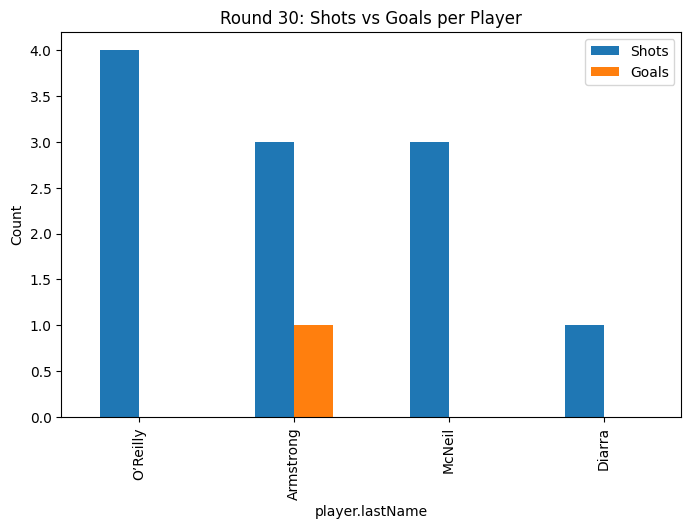

In [73]:
import matplotlib.pyplot as plt

player_stats[['Shots','Goals']].plot(kind='bar', figsize=(8,5))
plt.title("Round 30: Shots vs Goals per Player")
plt.ylabel("Count")
plt.show()

# Scatter: Goals vs xG

/tmp/ipykernel_7586/710201560.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(player_stats["Total_xG"][i]+0.01, player_stats["Goals"][i], player)


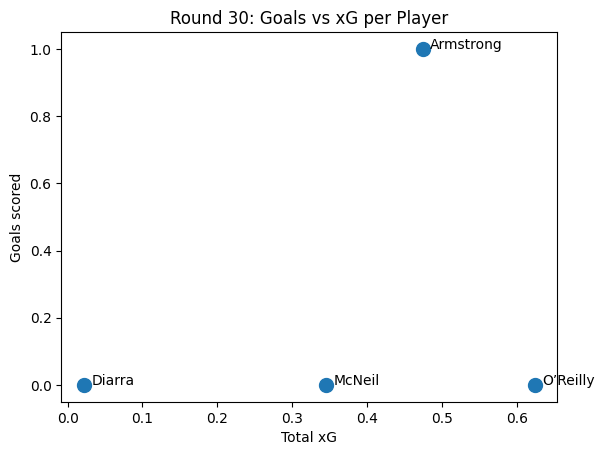

In [74]:
plt.scatter(player_stats["Total_xG"], player_stats["Goals"], s=100)
for i, player in enumerate(player_stats.index):
    plt.text(player_stats["Total_xG"][i]+0.01, player_stats["Goals"][i], player)
plt.xlabel("Total xG")
plt.ylabel("Goals scored")
plt.title("Round 30: Goals vs xG per Player")
plt.show()

# Shot map: For the top player

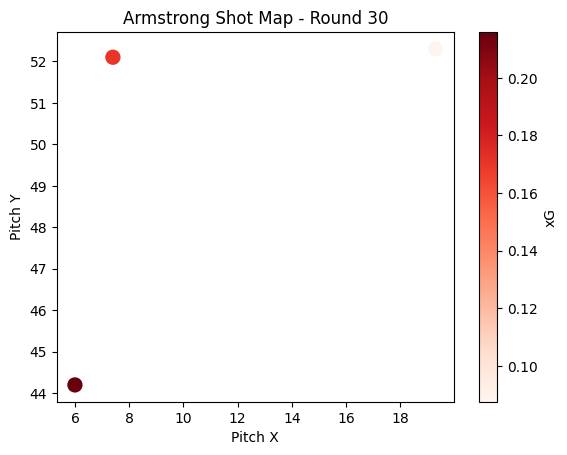

In [76]:
top_player = "Armstrong"
top_shots_df = shots_df[shots_df["player.lastName"]==top_player]

plt.scatter(top_shots_df["playerCoordinates.x"], top_shots_df["playerCoordinates.y"], c=top_shots_df["xg"], cmap="Reds", s=100)
plt.xlabel("Pitch X")
plt.ylabel("Pitch Y")
plt.title(f"{top_player} Shot Map - Round 30")
plt.colorbar(label="xG")
plt.show()